# Analyse des vues LLM dans les portefeuilles Black-Litterman



In [1]:
import os
import json
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.options.display.float_format = "{:,.4f}".format

# ============================
# Configuration
# ============================

DATASET_PATH = Path("../data/filtered_sp25_data.csv")
RESPONSES_DIR = Path("../responses")
RESULTS_DIR = Path("../results")
OUT_DIR = Path("diagnostics_views_blended")
OUT_DIR.mkdir(parents=True, exist_ok=True)

START = "2015-01-01"
END = "2025-06-30"
TAU = 0.01

# Modèles à analyser. Le nouveau modèle GPT-5.4 mini peut être appelé avec
# l'alias court du projet ou avec son identifiant OpenAI officiel.
GPT54MINI_PREFIXES = ["gpt54mini", "gpt-5.4-mini", "gpt-5.4-mini-2026-03-17"]
MODELS = ["gpt", "gpt54mini", "gemma3", "llama", "qwen"]

# Préfixes de fichiers de réponses à essayer pour chaque modèle. Cela permet au
# notebook de fonctionner même si run.py a été exécuté avec un alias différent
# pour GPT-5.4 mini.
MODEL_RESPONSE_PREFIXES = {
    "gpt54mini": GPT54MINI_PREFIXES,
    "gpt-5.4-mini": GPT54MINI_PREFIXES,
    "gpt-5.4-mini-2026-03-17": GPT54MINI_PREFIXES,
}


## 1. Fonctions utilitaires


In [2]:
def clean_ticker(x) -> str:
    if x is None:
        return ""
    s = str(x).strip().strip('"').strip("'").upper()
    if not s or s in {"NAN", "NONE"}:
        return ""
    if "-" in s and "." not in s:
        s = s.replace("-", ".")
    return "".join(s.split())

def parse_dates_yyyymmdd(s: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(s):
        ss = pd.to_numeric(s, errors="coerce").astype("Int64").astype(str).str.zfill(8)
        return pd.to_datetime(ss, format="%Y%m%d", errors="coerce")
    ss = s.astype(str).str.strip()
    out = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")
    mask = ss.str.match(r"^\d{8}$", na=False)
    out.loc[mask] = pd.to_datetime(ss.loc[mask], format="%Y%m%d", errors="coerce")
    out.loc[~mask] = pd.to_datetime(ss.loc[~mask], errors="coerce")
    return out

def month_starts_between(start: str, end: str) -> pd.DatetimeIndex:
    return pd.date_range(pd.to_datetime(start), pd.to_datetime(end), freq="MS")

def month_end_from_period(p: pd.Period) -> pd.Timestamp:
    return p.to_timestamp(how="end").normalize()

def response_prefix_candidates(model: str) -> list[str]:
    """Return possible response-file prefixes for a requested model."""
    m = str(model).strip().lower()
    candidates = MODEL_RESPONSE_PREFIXES.get(m, [m])
    out = []
    for c in candidates:
        c = str(c).strip().lower()
        if c and c not in out:
            out.append(c)
    return out


def infer_model_from_portfolio_id(portfolio_id: str) -> str:
    p = str(portfolio_id).lower()
    for m in MODELS:
        for prefix in response_prefix_candidates(m):
            if p.startswith(prefix.lower()):
                return m
    return p.split("_")[0]

def safe_corr(x, y) -> float:
    x = pd.Series(x, dtype=float)
    y = pd.Series(y, dtype=float)
    ok = x.notna() & y.notna() & np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 3:
        return np.nan
    if x.loc[ok].std(ddof=1) <= 1e-15 or y.loc[ok].std(ddof=1) <= 1e-15:
        return np.nan
    return float(x.loc[ok].corr(y.loc[ok]))

def hit_rate(x, y) -> float:
    x = pd.Series(x, dtype=float)
    y = pd.Series(y, dtype=float)
    ok = x.notna() & y.notna() & np.isfinite(x) & np.isfinite(y)
    ok &= (x != 0) & (y != 0)
    if ok.sum() == 0:
        return np.nan
    return float((np.sign(x.loc[ok]) == np.sign(y.loc[ok])).mean())

def long_short_spread(view: pd.Series, realized: pd.Series, q: float = 0.2) -> float:
    df = pd.concat([view.rename("view"), realized.rename("ret")], axis=1).dropna()
    if len(df) < 5:
        return np.nan
    n = max(1, int(np.floor(q * len(df))))
    top = df.nlargest(n, "view")["ret"].mean()
    bottom = df.nsmallest(n, "view")["ret"].mean()
    return float(top - bottom)

def top_bottom_hit(view: pd.Series, realized: pd.Series, q: float = 0.2) -> float:
    df = pd.concat([view.rename("view"), realized.rename("ret")], axis=1).dropna()
    if len(df) < 5:
        return np.nan
    n = max(1, int(np.floor(q * len(df))))
    top_idx = df.nlargest(n, "view").index
    bottom_idx = df.nsmallest(n, "view").index
    top_good = (df.loc[top_idx, "ret"] > df["ret"].median()).mean()
    bottom_good = (df.loc[bottom_idx, "ret"] < df["ret"].median()).mean()
    return float(0.5 * (top_good + bottom_good))

def annualized_return(r: pd.Series) -> float:
    r = pd.Series(r, dtype=float).dropna()
    if len(r) == 0:
        return np.nan
    return float((1 + r).prod() ** (12 / len(r)) - 1)

def max_drawdown(r: pd.Series) -> float:
    r = pd.Series(r, dtype=float).dropna()
    if len(r) == 0:
        return np.nan
    wealth = (1 + r).cumprod()
    dd = wealth / wealth.cummax() - 1
    return float(dd.min())


## 2. Chargement des données SP25 et calcul du benchmark cap-weighted


In [3]:
def load_sp25_dataset(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)
    required = {"date", "tic", "stock_ret", "market_equity"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Colonnes manquantes dans {path}: {missing}")
    df = df.copy()
    df["date_dt"] = parse_dates_yyyymmdd(df["date"])
    df["tic"] = df["tic"].map(clean_ticker)
    df["stock_ret"] = pd.to_numeric(df["stock_ret"], errors="coerce")
    df["market_equity"] = pd.to_numeric(df["market_equity"], errors="coerce")
    df = df.dropna(subset=["date_dt", "tic"]).copy()
    df = df[df["tic"] != ""].copy()
    df["ym"] = df["date_dt"].dt.to_period("M")
    df = df.sort_values(["ym", "tic", "date_dt"])
    df = df.drop_duplicates(["ym", "tic"], keep="last")
    return df

sp25_df = load_sp25_dataset(DATASET_PATH)

returns_panel = (
    sp25_df.pivot(index="ym", columns="tic", values="stock_ret")
    .sort_index()
)

mcap_panel = (
    sp25_df.pivot(index="ym", columns="tic", values="market_equity")
    .sort_index()
)

market_weights = mcap_panel.where(mcap_panel > 0)
market_weights = market_weights.div(market_weights.sum(axis=1), axis=0).fillna(0.0)

def compute_sp25_returns_from_lagged_weights(start: str, end: str) -> pd.Series:
    out = {}
    for m0 in month_starts_between(start, end):
        weight_p = m0.to_period("M")
        target_p = (m0 + pd.offsets.MonthBegin(1)).to_period("M")
        if weight_p not in market_weights.index or target_p not in returns_panel.index:
            continue
        w = market_weights.loc[weight_p]
        r = returns_panel.loc[target_p]
        ok = r.notna() & w.notna() & np.isfinite(r) & np.isfinite(w)
        if ok.sum() == 0:
            continue
        denom = w.loc[ok].sum()
        if denom <= 1e-12:
            continue
        out[month_end_from_period(target_p)] = float((w.loc[ok] * r.loc[ok]).sum() / denom)
    return pd.Series(out, name="sp25_return").sort_index()

sp25_returns = compute_sp25_returns_from_lagged_weights(START, END)

print("Dataset SP25:", returns_panel.index.min(), "->", returns_panel.index.max(), "| tickers:", returns_panel.shape[1])
print("Benchmark S&P25:", sp25_returns.index.min(), "->", sp25_returns.index.max(), "| n:", len(sp25_returns))
display(sp25_returns.head())


Dataset SP25: 2014-12 -> 2025-06 | tickers: 43
Benchmark S&P25: 2015-02-28 00:00:00 -> 2025-06-30 00:00:00 | n: 125


2015-02-28    0.0548
2015-03-31   -0.0278
2015-04-30    0.0321
2015-05-31    0.0080
2015-06-30   -0.0247
Name: sp25_return, dtype: float64

## 3. Chargement des vues LLM


In [4]:
def load_response_file(path: Path) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    out = {}
    for k, v in raw.items():
        t = clean_ticker(k)
        if not t or not isinstance(v, dict):
            continue

        samples = v.get("expected_return", None)

        if isinstance(samples, list):
            s = pd.to_numeric(pd.Series(samples), errors="coerce").dropna()
        else:
            s = pd.to_numeric(pd.Series([samples]), errors="coerce").dropna()

        if len(s) == 0:
            continue

        out[t] = {
            "view_mean": float(s.mean()),
            "view_median": float(s.median()),
            "view_std": float(s.std(ddof=1)) if len(s) > 1 else np.nan,
            "view_var": float(s.var(ddof=1)) if len(s) > 1 else np.nan,
            "view_n": int(len(s)),
        }
    return out


def find_response_file(responses_dir: Path, model: str, start_date: str, end_date: str) -> Path | None:
    """
    Find the monthly response file for a model.

    For GPT-5.4 mini, the same run can be saved under one of several prefixes:
    gpt54mini, gpt-5.4-mini, or gpt-5.4-mini-2026-03-17.
    """
    for prefix in response_prefix_candidates(model):
        path = responses_dir / f"{prefix}_{start_date}_{end_date}.json"
        if path.exists():
            return path
    return None


def build_views_panel(models, responses_dir: Path, start: str, end: str) -> pd.DataFrame:
    rows = []
    missing_counts = {m: 0 for m in models}
    used_files = {m: set() for m in models}

    for m0 in month_starts_between(start, end):
        start_date = m0.strftime("%Y-%m-%d")
        end_date = (m0 + pd.offsets.MonthEnd(1)).strftime("%Y-%m-%d")
        view_month = m0.to_period("M")
        target_month = (m0 + pd.offsets.MonthBegin(1)).to_period("M")
        target_date = month_end_from_period(target_month)

        for model in models:
            path = find_response_file(responses_dir, model, start_date, end_date)
            if path is None:
                missing_counts[model] = missing_counts.get(model, 0) + 1
                continue

            used_files[model].add(path.name)
            d = load_response_file(path)
            for tic, vals in d.items():
                realized = np.nan
                if target_month in returns_panel.index and tic in returns_panel.columns:
                    realized = returns_panel.loc[target_month, tic]

                rows.append({
                    "model": model,
                    "view_month": view_month,
                    "view_date": m0,
                    "target_month": target_month,
                    "target_date": target_date,
                    "tic": tic,
                    "realized_next_return": realized,
                    "response_file": path.name,
                    **vals,
                })

    if len(rows) == 0:
        raise ValueError("Aucune vue chargée. Vérifie MODELS, START/END et RESPONSES_DIR.")

    for model in models:
        n_used = len(used_files.get(model, set()))
        n_missing = missing_counts.get(model, 0)
        print(f"{model}: {n_used} fichiers de réponses chargés | {n_missing} mois manquants")

    df = pd.DataFrame(rows)
    df["view_sign"] = np.sign(df["view_mean"])
    df["realized_sign"] = np.sign(df["realized_next_return"])
    df["correct_sign"] = (
        df["view_sign"].ne(0)
        & df["realized_sign"].ne(0)
        & (df["view_sign"] == df["realized_sign"])
    )
    return df


views_long = build_views_panel(MODELS, RESPONSES_DIR, START, END)

print("Vues chargées:", views_long.shape)
display(views_long.head())


gpt: 126 fichiers de réponses chargés | 0 mois manquants
gpt54mini: 126 fichiers de réponses chargés | 0 mois manquants
gemma3: 126 fichiers de réponses chargés | 0 mois manquants
llama: 126 fichiers de réponses chargés | 0 mois manquants
qwen: 126 fichiers de réponses chargés | 0 mois manquants
Vues chargées: (14330, 16)


,model,view_month,view_date,target_month,target_date,tic,realized_next_return,response_file,view_mean,view_median,view_std,view_var,view_n,view_sign,realized_sign,correct_sign
0,gpt,2015-01,2015-01-01,2015-02,2015-02-28,AAPL,0.1005,gpt_2015-01-01_2015-01-31.json,0.0155,0.0155,0.0050,0.0000,30,1.0000,1.0000,True
1,gpt,2015-01,2015-01-01,2015-02,2015-02-28,AMZN,0.0723,gpt_2015-01-01_2015-01-31.json,0.0234,0.0237,0.0039,0.0000,30,1.0000,1.0000,True
2,gpt,2015-01,2015-01-01,2015-02,2015-02-28,BAC,0.0436,gpt_2015-01-01_2015-01-31.json,-0.0502,-0.0502,0.0002,0.0000,30,-1.0000,1.0000,False
3,gpt,2015-01,2015-01-01,2015-02,2015-02-28,BRK.B,0.0243,gpt_2015-01-01_2015-01-31.json,-0.0154,-0.0154,0.0001,0.0000,30,-1.0000,1.0000,False
4,gpt,2015-01,2015-01-01,2015-02,2015-02-28,CVX,0.0509,gpt_2015-01-01_2015-01-31.json,-0.0278,-0.0278,0.0000,0.0000,30,-1.0000,1.0000,False


## 4. Diagnostics mensuels des vues


In [5]:
monthly_rows = []

for (model, target_date), g in views_long.groupby(["model", "target_date"]):
    g = g.dropna(subset=["view_mean", "realized_next_return"]).copy()
    if len(g) == 0:
        continue

    view = g.set_index("tic")["view_mean"]
    ret = g.set_index("tic")["realized_next_return"]

    sp25_ret = sp25_returns.loc[target_date] if target_date in sp25_returns.index else np.nan

    if pd.isna(sp25_ret):
        regime = "unknown"
    elif sp25_ret >= 0.03:
        regime = "strong_up"
    elif sp25_ret > 0:
        regime = "up"
    elif sp25_ret <= -0.03:
        regime = "strong_down"
    else:
        regime = "down"

    n_top = max(1, int(0.2 * len(view))) if len(view) >= 5 else np.nan

    monthly_rows.append({
        "model": model,
        "target_date": target_date,
        "n_views": len(g),
        "sp25_return": sp25_ret,
        "market_regime": regime,
        "view_mean_avg": float(view.mean()),
        "view_median_avg": float(view.median()),
        "view_std_cross_section": float(view.std(ddof=1)) if len(view) > 1 else np.nan,
        "view_pos_frac": float((view > 0).mean()),
        "view_neg_frac": float((view < 0).mean()),
        "realized_avg": float(ret.mean()),
        "view_realized_corr": safe_corr(view, ret),
        "view_realized_rank_corr": safe_corr(view.rank(), ret.rank()),
        "view_hit_rate": hit_rate(view, ret),
        "top_bottom_spread_q20": long_short_spread(view, ret, q=0.2),
        "top_bottom_hit_q20": top_bottom_hit(view, ret, q=0.2),
    })

views_monthly = pd.DataFrame(monthly_rows).sort_values(["model", "target_date"]).reset_index(drop=True)

views_summary = (
    views_monthly.groupby("model")
    .agg(
        n_months=("target_date", "nunique"),
        avg_n_views=("n_views", "mean"),
        avg_view_realized_corr=("view_realized_corr", "mean"),
        median_view_realized_corr=("view_realized_corr", "median"),
        avg_rank_corr=("view_realized_rank_corr", "mean"),
        avg_hit_rate=("view_hit_rate", "mean"),
        avg_top_bottom_spread_q20=("top_bottom_spread_q20", "mean"),
        median_top_bottom_spread_q20=("top_bottom_spread_q20", "median"),
        avg_top_bottom_hit_q20=("top_bottom_hit_q20", "mean"),
        avg_view_pos_frac=("view_pos_frac", "mean"),
        avg_view_std_cross_section=("view_std_cross_section", "mean"),
    )
    .reset_index()
)

display(views_monthly.head())
display(views_summary.sort_values("avg_top_bottom_spread_q20", ascending=False))


,model,target_date,n_views,sp25_return,market_regime,view_mean_avg,view_median_avg,view_std_cross_section,view_pos_frac,view_neg_frac,realized_avg,view_realized_corr,view_realized_rank_corr,view_hit_rate,top_bottom_spread_q20,top_bottom_hit_q20
0,gemma3,2015-02-28,21,0.0548,strong_up,0.0043,0.0091,0.0180,0.5714,0.3810,0.0506,0.2001,0.2092,0.6000,0.0251,0.6250
1,gemma3,2015-03-31,20,-0.0278,down,0.0119,0.0144,0.0148,0.8000,0.1500,-0.0261,0.4102,0.4346,0.2105,0.0174,0.5000
2,gemma3,2015-04-30,22,0.0321,strong_up,0.0121,0.0164,0.0157,0.8182,0.1364,0.0283,0.1812,0.2343,0.6667,0.0474,0.5000
3,gemma3,2015-05-31,23,0.0080,up,0.0159,0.0180,0.0164,0.8696,0.1304,0.0115,0.0980,0.0731,0.5652,0.0023,0.6250
4,gemma3,2015-06-30,22,-0.0247,down,0.0093,0.0171,0.0176,0.7727,0.2273,-0.0219,-0.1977,-0.2264,0.3636,-0.0542,0.2500


,model,n_months,avg_n_views,avg_view_realized_corr,median_view_realized_corr,avg_rank_corr,avg_hit_rate,avg_top_bottom_spread_q20,median_top_bottom_spread_q20,avg_top_bottom_hit_q20,avg_view_pos_frac,avg_view_std_cross_section
2,gpt54mini,125,22.9280,0.0795,0.0914,0.0543,0.5661,0.0140,0.0102,0.5156,0.9360,0.0109
1,gpt,125,22.6880,0.0069,0.0120,0.0058,0.5346,0.0050,0.0065,0.4978,0.8244,0.0195
0,gemma3,125,22.6880,0.0015,0.0041,0.0051,0.5516,0.0049,0.0083,0.4903,0.8942,0.0171
3,llama,125,22.6880,0.0085,-0.0086,0.0039,0.4351,0.0035,0.0042,0.5037,0.1073,0.0136
4,qwen,125,22.6880,-0.0033,-0.0604,-0.0099,0.4860,0.0020,-0.0067,0.4992,0.4235,0.0500


## 5. Analyse par régime de marché


,model,market_regime,n_months,avg_sp25_return,avg_view_corr,avg_rank_corr,avg_hit_rate,avg_top_bottom_spread,avg_top_bottom_hit,avg_view_pos_frac,avg_view_mean,avg_view_dispersion
0,gemma3,down,18,-0.0129,-0.0859,-0.0410,0.4424,-0.0160,0.4056,0.8727,0.0179,0.0176
1,gemma3,strong_down,22,-0.0631,-0.0723,-0.0845,0.2501,-0.0111,0.4458,0.8922,0.0188,0.0197
2,gemma3,strong_up,47,0.0608,0.0521,0.0698,0.6975,0.0191,0.5470,0.8759,0.0175,0.0181
3,gemma3,up,38,0.0153,0.0229,-0.0011,0.5975,0.0067,0.4862,0.9283,0.0199,0.0142
4,gpt,down,18,-0.0129,-0.0612,-0.0338,0.4480,-0.0109,0.4431,0.7863,0.0158,0.0194
5,gpt,strong_down,22,-0.0631,-0.2026,-0.1579,0.2714,-0.0272,0.3973,0.8476,0.0177,0.0225
6,gpt,strong_up,47,0.0608,0.1388,0.1163,0.6544,0.0302,0.5695,0.7799,0.0149,0.0206
7,gpt,up,38,0.0153,-0.0026,-0.0174,0.5797,-0.0001,0.4932,0.8839,0.0185,0.0165
8,gpt54mini,down,18,-0.0129,0.0240,0.0294,0.4444,0.0068,0.5208,0.9194,0.0141,0.0111
9,gpt54mini,strong_down,22,-0.0631,-0.2196,-0.2139,0.2114,-0.0361,0.3572,0.9312,0.0155,0.0120


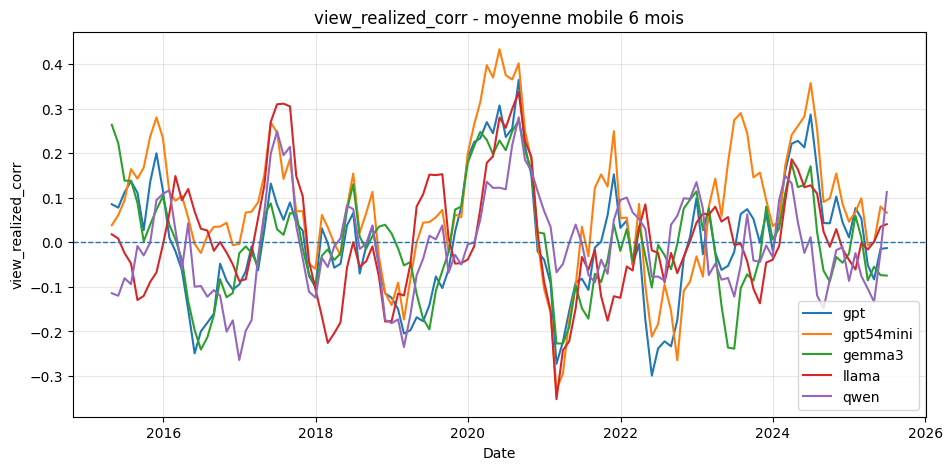

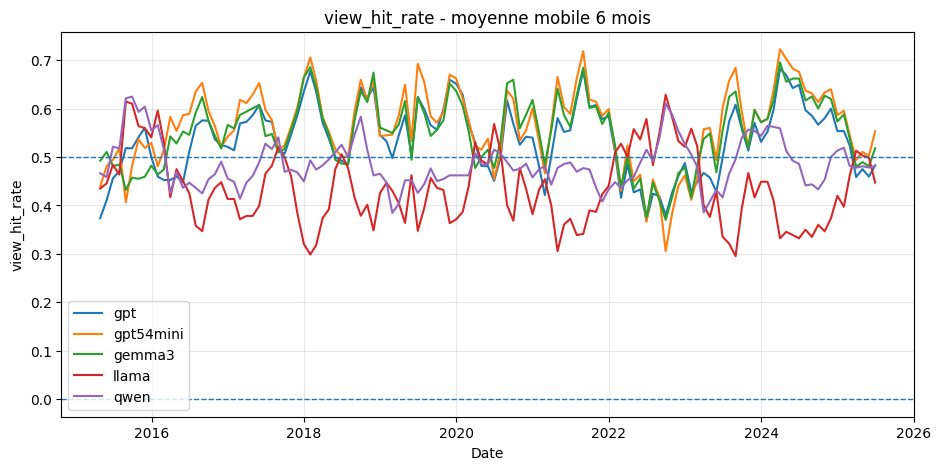

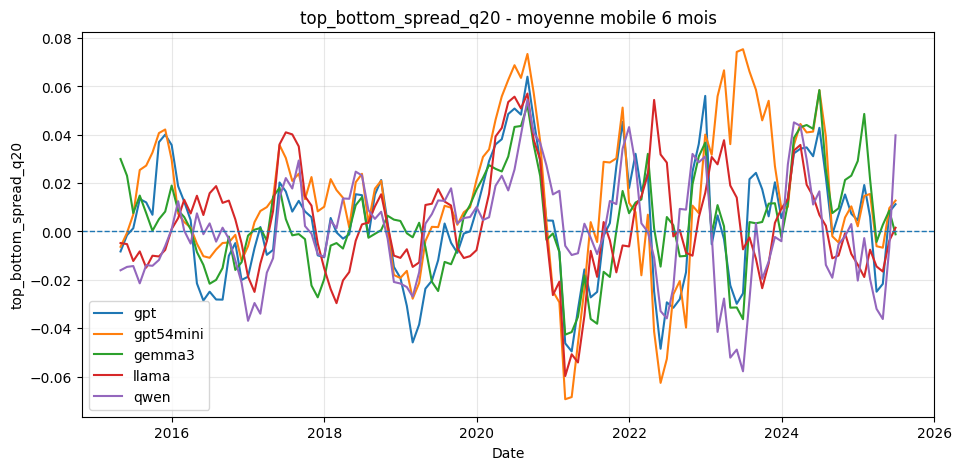

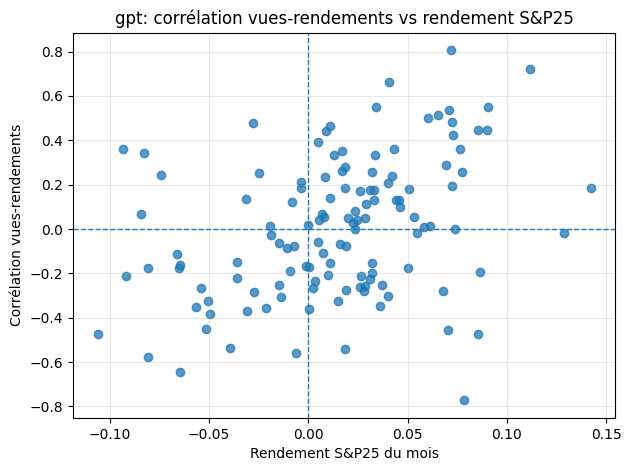

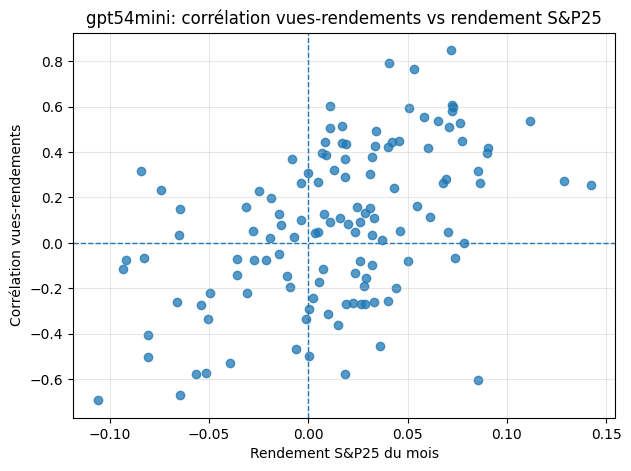

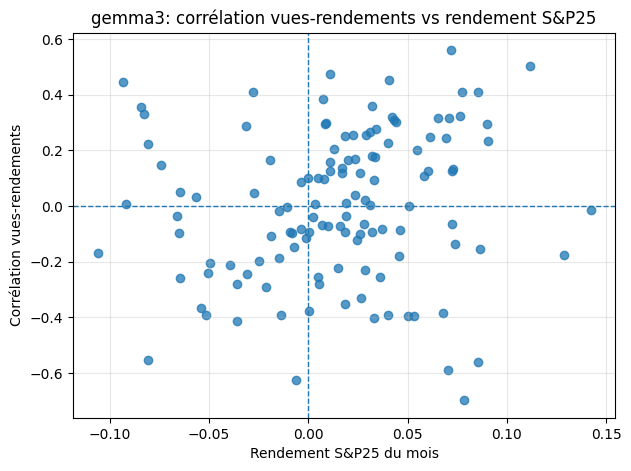

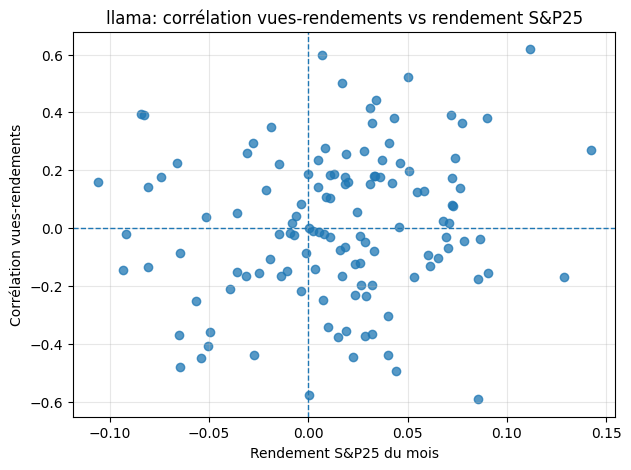

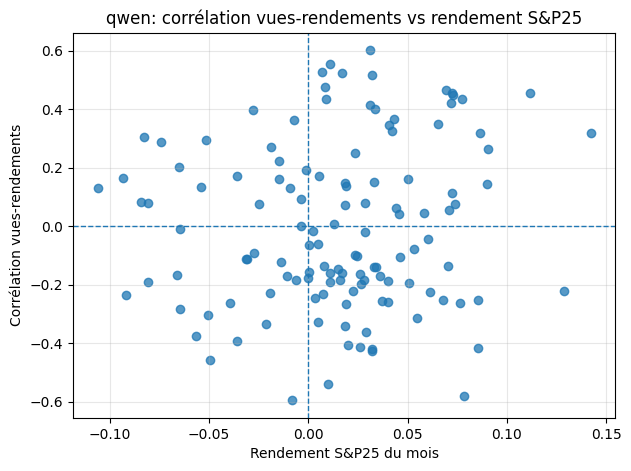

In [6]:
regime_summary = (
    views_monthly.groupby(["model", "market_regime"])
    .agg(
        n_months=("target_date", "nunique"),
        avg_sp25_return=("sp25_return", "mean"),
        avg_view_corr=("view_realized_corr", "mean"),
        avg_rank_corr=("view_realized_rank_corr", "mean"),
        avg_hit_rate=("view_hit_rate", "mean"),
        avg_top_bottom_spread=("top_bottom_spread_q20", "mean"),
        avg_top_bottom_hit=("top_bottom_hit_q20", "mean"),
        avg_view_pos_frac=("view_pos_frac", "mean"),
        avg_view_mean=("view_mean_avg", "mean"),
        avg_view_dispersion=("view_std_cross_section", "mean"),
    )
    .reset_index()
    .sort_values(["model", "market_regime"])
)

display(regime_summary)

for metric in ["view_realized_corr", "view_hit_rate", "top_bottom_spread_q20"]:
    plt.figure(figsize=(11, 5))
    for model in MODELS:
        d = views_monthly[views_monthly["model"] == model].sort_values("target_date")
        if d.empty:
            continue
        plt.plot(d["target_date"], d[metric].rolling(6, min_periods=3).mean(), label=model)
    plt.axhline(0, linestyle="--", linewidth=1)
    if metric == "view_hit_rate":
        plt.axhline(0.5, linestyle="--", linewidth=1)
    plt.title(f"{metric} - moyenne mobile 6 mois")
    plt.xlabel("Date")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

for model in MODELS:
    d = views_monthly[views_monthly["model"] == model].dropna(subset=["sp25_return", "view_realized_corr"])
    if d.empty:
        continue
    plt.figure(figsize=(7, 5))
    plt.scatter(d["sp25_return"], d["view_realized_corr"], alpha=0.75)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.title(f"{model}: corrélation vues-rendements vs rendement S&P25")
    plt.xlabel("Rendement S&P25 du mois")
    plt.ylabel("Corrélation vues-rendements")
    plt.grid(True, alpha=0.3)
    plt.show()


## 6. Comparaison des vues entre modèles


,pair,n_months,avg_view_corr,avg_rank_corr,avg_sign_agreement,avg_top20_jaccard,avg_bottom20_jaccard
4,gpt vs gpt54mini,125,0.7324,0.7383,0.8734,0.4971,0.4455
0,gemma3 vs gpt,125,0.5954,0.5878,0.8554,0.4064,0.3573
1,gemma3 vs gpt54mini,125,0.5244,0.5226,0.9015,0.3603,0.3294
6,gpt vs qwen,125,0.4053,0.4236,0.5791,0.2727,0.2476
9,llama vs qwen,125,0.3919,0.3916,0.6464,0.2326,0.2486
5,gpt vs llama,125,0.3205,0.2866,0.2827,0.1938,0.2143
3,gemma3 vs qwen,125,0.2990,0.3064,0.5119,0.2496,0.1970
8,gpt54mini vs qwen,125,0.2988,0.3201,0.4835,0.2464,0.1746
7,gpt54mini vs llama,125,0.2968,0.2740,0.1717,0.2360,0.1799
2,gemma3 vs llama,125,0.1682,0.1272,0.2057,0.1430,0.1802


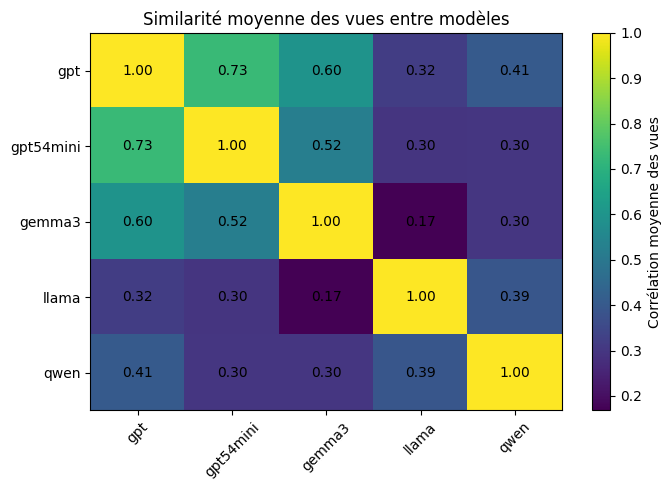

In [7]:
inter_rows = []

for target_date, gdate in views_long.groupby("target_date"):
    models_present = sorted(gdate["model"].unique())
    for m1, m2 in combinations(models_present, 2):
        g1 = gdate[gdate["model"] == m1].set_index("tic")
        g2 = gdate[gdate["model"] == m2].set_index("tic")
        common = g1.index.intersection(g2.index)

        if len(common) < 3:
            continue

        v1 = g1.loc[common, "view_mean"]
        v2 = g2.loc[common, "view_mean"]

        n_top = max(1, int(0.2 * len(common)))
        top1 = set(v1.nlargest(n_top).index)
        top2 = set(v2.nlargest(n_top).index)
        bot1 = set(v1.nsmallest(n_top).index)
        bot2 = set(v2.nsmallest(n_top).index)

        top_jaccard = len(top1 & top2) / len(top1 | top2) if len(top1 | top2) > 0 else np.nan
        bottom_jaccard = len(bot1 & bot2) / len(bot1 | bot2) if len(bot1 | bot2) > 0 else np.nan
        sign_agree = float((np.sign(v1) == np.sign(v2)).mean())

        inter_rows.append({
            "target_date": target_date,
            "model_1": m1,
            "model_2": m2,
            "pair": f"{m1} vs {m2}",
            "n_common": len(common),
            "view_corr": safe_corr(v1, v2),
            "view_rank_corr": safe_corr(v1.rank(), v2.rank()),
            "sign_agreement": sign_agree,
            "top20_jaccard": float(top_jaccard),
            "bottom20_jaccard": float(bottom_jaccard),
        })

inter_model_views = pd.DataFrame(inter_rows)

inter_summary = (
    inter_model_views.groupby("pair")
    .agg(
        n_months=("target_date", "nunique"),
        avg_view_corr=("view_corr", "mean"),
        avg_rank_corr=("view_rank_corr", "mean"),
        avg_sign_agreement=("sign_agreement", "mean"),
        avg_top20_jaccard=("top20_jaccard", "mean"),
        avg_bottom20_jaccard=("bottom20_jaccard", "mean"),
    )
    .reset_index()
    .sort_values("avg_view_corr", ascending=False)
)

display(inter_summary)

corr_mat = pd.DataFrame(index=MODELS, columns=MODELS, dtype=float)
for m in MODELS:
    corr_mat.loc[m, m] = 1.0

for _, row in inter_summary.iterrows():
    m1, _, m2 = row["pair"].partition(" vs ")
    corr_mat.loc[m1, m2] = corr_mat.loc[m2, m1] = row["avg_view_corr"]

plt.figure(figsize=(7, 5))
plt.imshow(corr_mat.astype(float), aspect="auto")
plt.colorbar(label="Corrélation moyenne des vues")
plt.xticks(range(len(corr_mat.columns)), corr_mat.columns, rotation=45)
plt.yticks(range(len(corr_mat.index)), corr_mat.index)
plt.title("Similarité moyenne des vues entre modèles")
for i in range(len(corr_mat.index)):
    for j in range(len(corr_mat.columns)):
        val = corr_mat.iloc[i, j]
        if pd.notna(val):
            plt.text(j, i, f"{val:.2f}", ha="center", va="center")
plt.tight_layout()
plt.show()
